## Claude Code

### Data recovered

  ↓ Downloading: Anisotropic_FD_Model_Shots_part1.sgy.gz


Anisotropic_FD_Model_Shots_part1.sgy.gz: 0.00B [00:00, ?B/s]

  ↓ Downloading: Anisotropic_FD_Model_Shots_part2.sgy.gz


Anisotropic_FD_Model_Shots_part2.sgy.gz: 0.00B [00:00, ?B/s]

  ↓ Downloading: Anisotropic_FD_Model_Shots_part3.sgy.gz


...

  ↓ Downloading: README_Modification.txt


README_Modification.txt: 0.00B [00:00, ?B/s]


All downloads complete.

Extracting compressed files …
  📦 Extracting: Anisotropic_FD_Model_Shots_part1.sgy.gz
  📦 Extracting: Anisotropic_FD_Model_Shots_part2.sgy.gz
  📦 Extracting: Anisotropic_FD_Model_Shots_part3.sgy.gz
  📦 Extracting: Anisotropic_FD_Model_Shots_part4.sgy.gz
  📦 Extracting: Anisotropic_FD_Model_VSP.tar.gz


/tmp/ipykernel_243/3961099365.py:80: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_dir)


  📦 Extracting: ModelParams.tar.gz
  📦 Extracting: OtherFiles-2.tar.gz

Extraction complete.

Model SEG-Y files found:
  ModelParams/ModelParams/Epsilon_Model.sgy
  ModelParams/ModelParams/Delta_Model.sgy
  ModelParams/ModelParams/Vp_Model.sgy
  ModelParams/ModelParams/Theta_Model.sgy

Using Vp model file: Vp_Model.sgy
  Shape  : 1801 depth samples × 12596 traces
  Vp range: 1492 – 4554 m/s


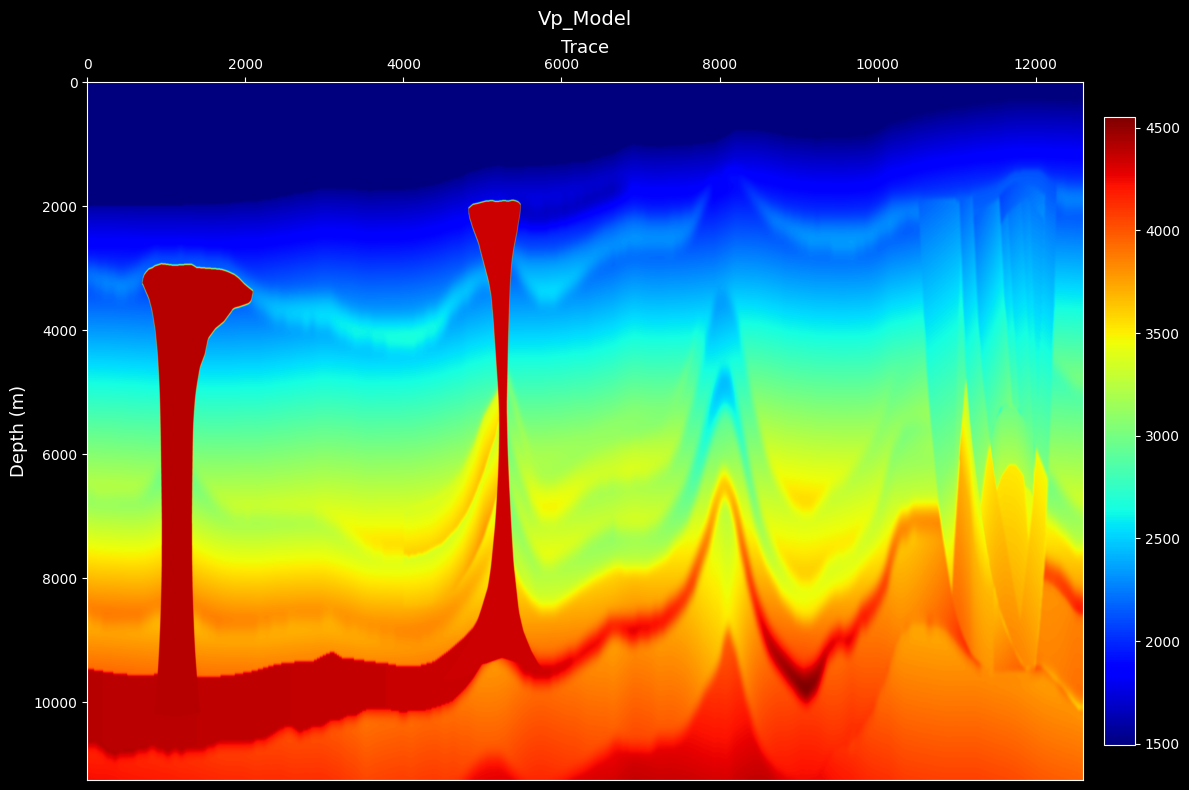

Plot saved as Vp_Model_BP2007.png

Loading a preview of shot gathers (part 1) …


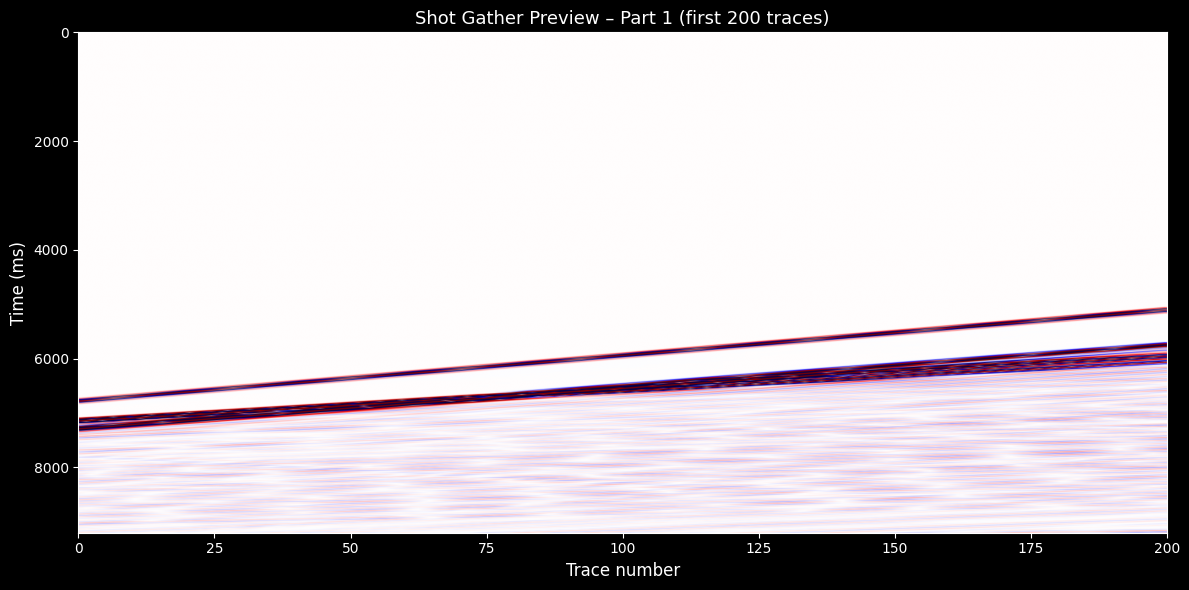

Shot-gather preview saved as ShotGather_Preview_BP2007.png


In [5]:
# ============================================================
# 2007 BP Anisotropic Velocity Benchmark – Download & Plot
# Designed for Google Colab
# ============================================================

# ── CELL 1 ─ Install dependencies ───────────────────────────
!pip install segyio matplotlib numpy tqdm

# ── CELL 2 ─ Imports ────────────────────────────────────────
import os
import gzip
import tarfile
import shutil
import urllib.request
from pathlib import Path
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import segyio

# ── CELL 3 ─ Download helpers ────────────────────────────────
BASE_URL = "http://s3.amazonaws.com/open.source.geoscience/open_data/bptti2007/"

FILES = {
    "shots_part1":   "Anisotropic_FD_Model_Shots_part1.sgy.gz",
    "shots_part2":   "Anisotropic_FD_Model_Shots_part2.sgy.gz",
    "shots_part3":   "Anisotropic_FD_Model_Shots_part3.sgy.gz",
    "shots_part4":   "Anisotropic_FD_Model_Shots_part4.sgy.gz",
    "vsp":           "Anisotropic_FD_Model_VSP.tar.gz",
    "disclaimer":    "DatasetInformation_And_Disclaimer.txt",
    "model_params":  "ModelParams.tar.gz",
    "other_files":   "OtherFiles-2.tar.gz",
    "readme":        "README_Modification.txt",
}

DATA_DIR = Path("bp2007_data")
DATA_DIR.mkdir(exist_ok=True)


class DownloadProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)


def download_file(url: str, dest: Path) -> Path:
    """Download a single file with a progress bar; skip if already present."""
    if dest.exists():
        print(f"  ✓ Already downloaded: {dest.name}")
        return dest
    print(f"  ↓ Downloading: {dest.name}")
    with DownloadProgressBar(unit="B", unit_scale=True, miniters=1, desc=dest.name) as t:
        urllib.request.urlretrieve(url, dest, reporthook=t.update_to)
    return dest


def extract_gz(gz_path: Path) -> Path:
    """Decompress a .sgy.gz file → .sgy (same directory)."""
    out_path = gz_path.with_suffix("")          # removes .gz
    if out_path.exists():
        print(f"  ✓ Already extracted: {out_path.name}")
        return out_path
    print(f"  📦 Extracting: {gz_path.name}")
    with gzip.open(gz_path, "rb") as f_in, open(out_path, "wb") as f_out:
        shutil.copyfileobj(f_in, f_out)
    return out_path


def extract_tar(tar_path: Path, extract_dir: Path) -> Path:
    """Extract a .tar.gz archive into extract_dir."""
    if extract_dir.exists():
        print(f"  ✓ Already extracted: {tar_path.name}")
        return extract_dir
    extract_dir.mkdir(parents=True, exist_ok=True)
    print(f"  📦 Extracting: {tar_path.name}")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=extract_dir)
    return extract_dir


# ── CELL 4 ─ Download all files ─────────────────────────────
print("=" * 60)
print("Downloading 2007 BP Anisotropic Velocity Benchmark data")
print("=" * 60)

downloaded = {}
for key, filename in FILES.items():
    url  = BASE_URL + filename
    dest = DATA_DIR / filename
    downloaded[key] = download_file(url, dest)

print("\nAll downloads complete.\n")

# ── CELL 5 ─ Extract archives ────────────────────────────────
print("Extracting compressed files …")

sgy_files = []
for i in range(1, 5):
    key   = f"shots_part{i}"
    gz    = downloaded[key]
    sgy   = extract_gz(gz)
    sgy_files.append(sgy)

vsp_dir    = extract_tar(downloaded["vsp"],          DATA_DIR / "VSP")
model_dir  = extract_tar(downloaded["model_params"], DATA_DIR / "ModelParams")
other_dir  = extract_tar(downloaded["other_files"],  DATA_DIR / "OtherFiles")

print("\nExtraction complete.\n")

# ── CELL 6 ─ Read SEG-Y model parameter files ───────────────
def find_segy_files(directory: Path):
    """Recursively find all .segy / .sgy files."""
    return list(directory.rglob("*.segy")) + list(directory.rglob("*.sgy"))


model_segy_files = find_segy_files(model_dir)
print("Model SEG-Y files found:")
for f in model_segy_files:
    print(" ", f.relative_to(DATA_DIR))


def load_segy_as_array(filepath: Path):
    """Read a SEG-Y file and return (data 2-D array, inline axis, crossline/trace axis)."""
    with segyio.open(str(filepath), ignore_geometry=True) as f:
        data = segyio.collect(f.trace[:])          # shape: (n_traces, n_samples)
        dt   = f.bin[segyio.BinField.Interval] / 1e6   # sample interval in seconds
        n_samples = data.shape[1]
    return data, dt


# ── CELL 7 ─ Plot Vp model (replicating the reference image) ─
# ------------------------------------------------------------------
# The Vp model is stored in the ModelParams archive as a SEG-Y file.
# Common filename patterns: *Vp* or *vp* or *velocity*.
# We search for the most likely candidate.
# ------------------------------------------------------------------

def find_model_file(directory: Path, keywords=("Vp", "vp", "VP", "velocity", "Velocity")):
    for kw in keywords:
        matches = list(directory.rglob(f"*{kw}*"))
        if matches:
            return matches[0]
    # Fallback: first SEG-Y found
    all_segy = find_segy_files(directory)
    return all_segy[0] if all_segy else None


vp_file = find_model_file(model_dir)
if vp_file is None:
    raise FileNotFoundError(
        "Could not find a Vp model SEG-Y file inside ModelParams. "
        "Please inspect DATA_DIR / 'ModelParams' and set vp_file manually."
    )

print(f"\nUsing Vp model file: {vp_file.name}")

# ── Load ────────────────────────────────────────────────────
with segyio.open(str(vp_file), ignore_geometry=True) as f:
    vp_data = segyio.collect(f.trace[:]).T    # shape: (n_samples, n_traces)
    dt_us   = f.bin[segyio.BinField.Interval]  # µs
    dz_m    = dt_us / 1e6 * 1000              # rough depth step (m) assuming v≈1000

n_depth, n_traces = vp_data.shape
depth_axis = np.arange(n_depth) * dz_m        # metres
trace_axis = np.arange(n_traces)

print(f"  Shape  : {n_depth} depth samples × {n_traces} traces")
print(f"  Vp range: {vp_data.min():.0f} – {vp_data.max():.0f} m/s")

# ── CELL 8 ─ High-fidelity plot matching the reference image ─
fig, ax = plt.subplots(figsize=(12, 8), facecolor="black")
ax.set_facecolor("black")

# Jet-style colormap that matches the rainbow palette in the reference
cmap = plt.cm.jet

im = ax.imshow(
    vp_data,
    aspect="auto",
    cmap=cmap,
    origin="upper",
    extent=[trace_axis[0], trace_axis[-1], depth_axis[-1], depth_axis[0]],
    interpolation="bilinear",
    vmin=vp_data.min(),
    vmax=vp_data.max(),
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("white")

# Axis labels & ticks – white on black to match reference
ax.tick_params(colors="white", which="both")
for spine in ax.spines.values():
    spine.set_edgecolor("white")

ax.set_xlabel("Trace",    color="white", fontsize=13)
ax.set_ylabel("Depth (m)", color="white", fontsize=13)
ax.set_title("Vp_Model",  color="white", fontsize=14, pad=10)

# Move x-axis labels to top (matching reference)
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()
ax.tick_params(axis="x", colors="white")

plt.tight_layout()
plt.savefig("Vp_Model_BP2007.png", dpi=150, bbox_inches="tight",
            facecolor="black", edgecolor="black")
plt.show()
print("Plot saved as Vp_Model_BP2007.png")


# ── CELL 9 (OPTIONAL) ─ Shot-gather overview ─────────────────
# Preview first 200 traces of part-1 shot gathers
print("\nLoading a preview of shot gathers (part 1) …")

with segyio.open(str(sgy_files[0]), ignore_geometry=True) as f:
    n_preview = min(200, f.tracecount)
    shot_data = np.array([f.trace[i] for i in range(n_preview)]).T
    dt_shot   = f.bin[segyio.BinField.Interval] / 1e6   # seconds
    t_axis    = np.arange(shot_data.shape[0]) * dt_shot * 1000  # ms

fig2, ax2 = plt.subplots(figsize=(12, 6), facecolor="black")
ax2.set_facecolor("black")

clip = np.percentile(np.abs(shot_data), 98)
ax2.imshow(
    shot_data,
    aspect="auto",
    cmap="seismic",
    origin="upper",
    vmin=-clip,
    vmax=clip,
    extent=[0, n_preview, t_axis[-1], t_axis[0]],
    interpolation="bilinear",
)

ax2.tick_params(colors="white")
for spine in ax2.spines.values():
    spine.set_edgecolor("white")

ax2.set_xlabel("Trace number", color="white", fontsize=12)
ax2.set_ylabel("Time (ms)",    color="white", fontsize=12)
ax2.set_title("Shot Gather Preview – Part 1 (first 200 traces)",
              color="white", fontsize=13)

plt.tight_layout()
plt.savefig("ShotGather_Preview_BP2007.png", dpi=150,
            bbox_inches="tight", facecolor="black")
plt.show()
print("Shot-gather preview saved as ShotGather_Preview_BP2007.png")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
  ↓ Downloading     : Anisotropic_FD_Model_Shots_part1.sgy.gz


Anisotropic_FD_Model_Shots_part1.sgy.gz: 0.00B [00:00, ?B/s]

  ↓ Downloading     : Anisotropic_FD_Model_Shots_part2.sgy.gz


Anisotropic_FD_Model_Shots_part2.sgy.gz: 0.00B [00:00, ?B/s]

  ↓ Downloading     : Anisotropic_FD_Model_Shots_part3.sgy.gz


...

  ↓ Downloading     : README_Modification.txt


README_Modification.txt: 0.00B [00:00, ?B/s]


All downloads complete.

Extracting archives …
  📦 Decompressing   : Anisotropic_FD_Model_Shots_part1.sgy.gz
  📦 Decompressing   : Anisotropic_FD_Model_Shots_part2.sgy.gz
  📦 Decompressing   : Anisotropic_FD_Model_Shots_part3.sgy.gz
  📦 Decompressing   : Anisotropic_FD_Model_Shots_part4.sgy.gz
  📦 Extracting      : Anisotropic_FD_Model_VSP.tar.gz


/tmp/ipykernel_169/3427437650.py:99: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=out_dir)


  📦 Extracting      : ModelParams.tar.gz
  📦 Extracting      : OtherFiles-2.tar.gz

Extraction complete.

Vp model file : Vp_Model.sgy
  Full model shape : 1801 × 12596
  Vp range         : 1492 – 4554 m/s


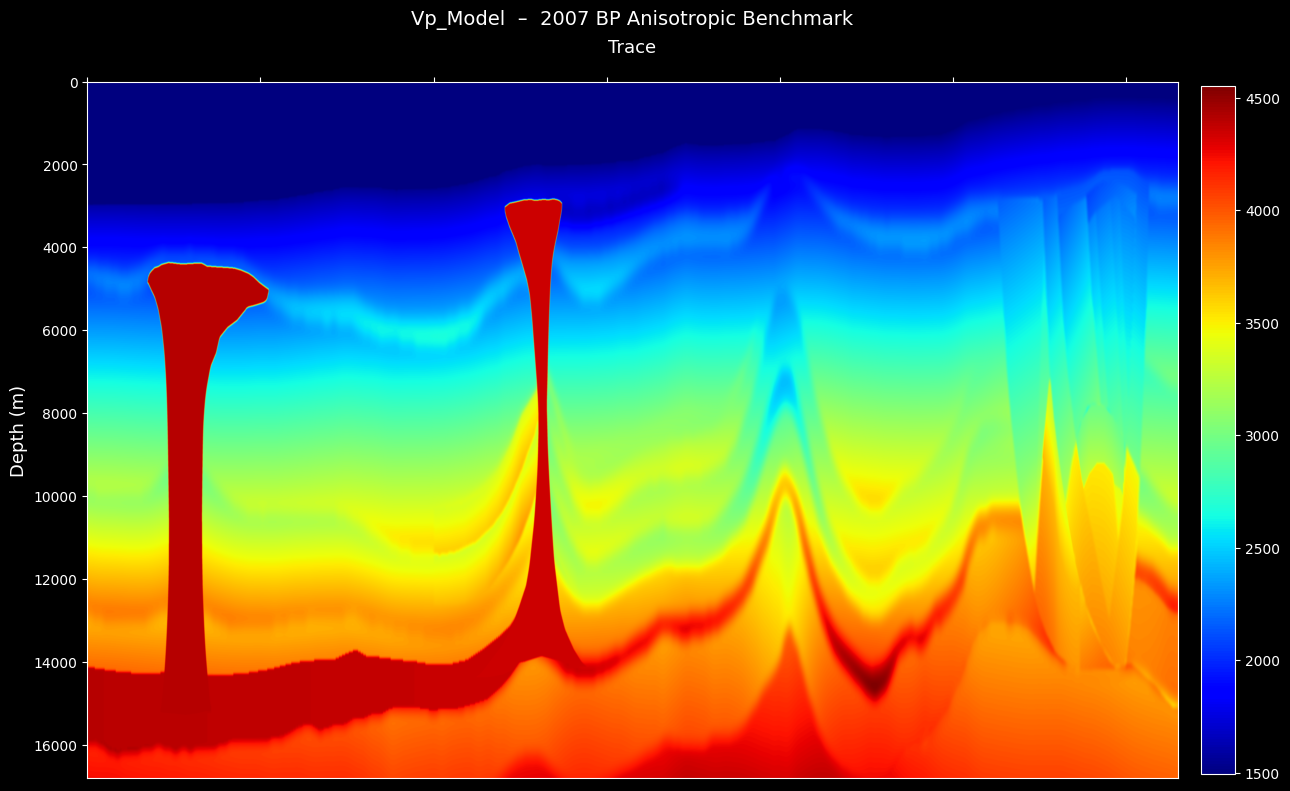

Saved → Vp_Model_BP2007.png
Subsampling by factor 8 …
  FWI grid         : 226 depth × 1575 lateral  (spacing 74.7 m)
  Vp range (sub)   : 1492 – 4548 m/s
Acquisition : 15 shots | 120 receivers/shot
Time axis   : 800 samples × 0.004 s = 3.2 s total
Running forward model on TRUE velocity …


/usr/local/lib/python3.12/dist-packages/deepwave/common.py:1191: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 5.0, a minimum non-zero velocity of 1492.0, and a grid cell spacing of 74.7155532836914, there are only 3.99.
  warnings.warn(


  Observed data shape : torch.Size([15, 120, 800])


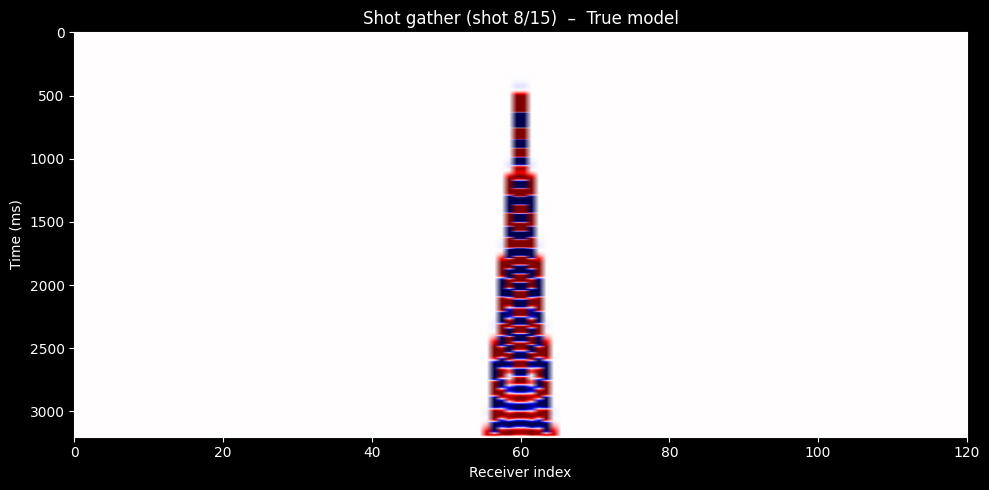

Starting FWI on 226×1575 grid for 800 epochs …


/usr/local/lib/python3.12/dist-packages/deepwave/common.py:1191: UserWarning: At least six grid cells per wavelength is recommended, but at a frequency of 5.0, a minimum non-zero velocity of 1501.738037109375, and a grid cell spacing of 74.7155532836914, there are only 4.02.
  warnings.warn(


OutOfMemoryError: CUDA out of memory. Tried to allocate 19.54 GiB. GPU 0 has a total capacity of 14.56 GiB of which 14.27 GiB is free. Including non-PyTorch memory, this process has 296.00 MiB memory in use. Of the allocated memory 167.44 MiB is allocated by PyTorch, and 10.56 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [2]:
# ================================================================
# 2007 BP Anisotropic Velocity Benchmark
# Full Workflow: Download → Plot → FWI → Pore Pressure Estimation
# Optimised for Google Colab T4 GPU
# ================================================================

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install dependencies                              ║
# ╚══════════════════════════════════════════════════════════════╝
!pip install segyio tqdm --quiet
!pip install git+https://github.com/ar4/deepwave.git --quiet

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports                                           ║
# ╚══════════════════════════════════════════════════════════════╝
import os
import gzip
import tarfile
import shutil
import urllib.request
from pathlib import Path
from tqdm.notebook import tqdm

import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import segyio
import deepwave
from deepwave import scalar

# ── GPU check ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Download helpers & file list                      ║
# ╚══════════════════════════════════════════════════════════════╝
BASE_URL = "http://s3.amazonaws.com/open.source.geoscience/open_data/bptti2007/"

FILES = {
    "shots_part1":  "Anisotropic_FD_Model_Shots_part1.sgy.gz",
    "shots_part2":  "Anisotropic_FD_Model_Shots_part2.sgy.gz",
    "shots_part3":  "Anisotropic_FD_Model_Shots_part3.sgy.gz",
    "shots_part4":  "Anisotropic_FD_Model_Shots_part4.sgy.gz",
    "vsp":          "Anisotropic_FD_Model_VSP.tar.gz",
    "disclaimer":   "DatasetInformation_And_Disclaimer.txt",
    "model_params": "ModelParams.tar.gz",
    "other_files":  "OtherFiles-2.tar.gz",
    "readme":       "README_Modification.txt",
}

DATA_DIR = Path("bp2007_data")
DATA_DIR.mkdir(exist_ok=True)


class ProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None:
            self.total = tsize
        self.update(b * bsize - self.n)


def download_file(url, dest):
    dest = Path(dest)
    if dest.exists():
        print(f"  ✓ Already present : {dest.name}")
        return dest
    print(f"  ↓ Downloading     : {dest.name}")
    with ProgressBar(unit="B", unit_scale=True, miniters=1, desc=dest.name) as t:
        urllib.request.urlretrieve(url, dest, reporthook=t.update_to)
    return dest


def extract_gz(gz_path):
    out = Path(gz_path).with_suffix("")
    if out.exists():
        print(f"  ✓ Already extracted: {out.name}")
        return out
    print(f"  📦 Decompressing   : {gz_path.name}")
    with gzip.open(gz_path, "rb") as fi, open(out, "wb") as fo:
        shutil.copyfileobj(fi, fo)
    return out


def extract_tar(tar_path, out_dir):
    out_dir = Path(out_dir)
    if out_dir.exists():
        print(f"  ✓ Already extracted: {tar_path.name}")
        return out_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"  📦 Extracting      : {tar_path.name}")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=out_dir)
    return out_dir


# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Download all files                                ║
# ╚══════════════════════════════════════════════════════════════╝
print("=" * 60)
print("  Downloading 2007 BP Anisotropic Benchmark data")
print("=" * 60)

downloaded = {}
for key, fname in FILES.items():
    downloaded[key] = download_file(BASE_URL + fname, DATA_DIR / fname)

print("\nAll downloads complete.\n")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Extract archives                                  ║
# ╚══════════════════════════════════════════════════════════════╝
print("Extracting archives …")

sgy_files = [extract_gz(downloaded[f"shots_part{i}"]) for i in range(1, 5)]

vsp_dir   = extract_tar(downloaded["vsp"],          DATA_DIR / "VSP")
model_dir = extract_tar(downloaded["model_params"], DATA_DIR / "ModelParams")
other_dir = extract_tar(downloaded["other_files"],  DATA_DIR / "OtherFiles")

print("\nExtraction complete.\n")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Locate & load the Vp model SEG-Y                  ║
# ╚══════════════════════════════════════════════════════════════╝
def find_segy(directory, keywords=("Vp", "vp", "VP", "velocity", "Velocity")):
    for kw in keywords:
        hits = list(Path(directory).rglob(f"*{kw}*"))
        segy_hits = [h for h in hits if h.suffix.lower() in (".sgy", ".segy")]
        if segy_hits:
            return segy_hits[0]
    all_segy = list(Path(directory).rglob("*.sgy")) + list(Path(directory).rglob("*.segy"))
    return all_segy[0] if all_segy else None


vp_file = find_segy(model_dir)
if vp_file is None:
    raise FileNotFoundError(
        "No Vp SEG-Y found in ModelParams. "
        "Run: list(Path('bp2007_data/ModelParams').rglob('*')) and set vp_file manually."
    )
print(f"Vp model file : {vp_file.name}")

# ── Read full Vp array ─────────────────────────────────────────
with segyio.open(str(vp_file), ignore_geometry=True) as f:
    vp_full = segyio.collect(f.trace[:]).T          # (n_depth, n_traces)
    dt_us   = f.bin[segyio.BinField.Interval]       # µs

n_depth_full, n_traces_full = vp_full.shape
print(f"  Full model shape : {n_depth_full} × {n_traces_full}")
print(f"  Vp range         : {vp_full.min():.0f} – {vp_full.max():.0f} m/s")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Plot the full Vp model (matches reference image)  ║
# ╚══════════════════════════════════════════════════════════════╝
dz_full = (dt_us / 1e6) * vp_full.mean() / 2      # rough depth sampling (m)
depth_ax_full = np.arange(n_depth_full) * dz_full
trace_ax_full = np.arange(n_traces_full)

fig, ax = plt.subplots(figsize=(13, 8), facecolor="black")
ax.set_facecolor("black")
im = ax.imshow(
    vp_full, aspect="auto", cmap="jet", origin="upper",
    extent=[trace_ax_full[0], trace_ax_full[-1], depth_ax_full[-1], depth_ax_full[0]],
    interpolation="bilinear",
    vmin=vp_full.min(), vmax=vp_full.max()
)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
for obj in [cbar.ax.yaxis, ax.xaxis, ax.yaxis]:
    obj.set_tick_params(color="white")
    plt.setp(obj.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("white")
for sp in ax.spines.values():
    sp.set_edgecolor("white")
ax.xaxis.set_label_position("top");  ax.xaxis.tick_top()
ax.set_xlabel("Trace", color="white", fontsize=13)
ax.set_ylabel("Depth (m)", color="white", fontsize=13)
ax.set_title("Vp_Model  –  2007 BP Anisotropic Benchmark",
             color="white", fontsize=14, pad=10)
plt.tight_layout()
plt.savefig("Vp_Model_BP2007.png", dpi=150, bbox_inches="tight",
            facecolor="black", edgecolor="black")
plt.show()
print("Saved → Vp_Model_BP2007.png")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Downsample model for FWI (T4 memory-safe)         ║
# ╚══════════════════════════════════════════════════════════════╝
# T4 has 16 GB VRAM. We subsample to keep tensors manageable.
# Adjust FACTOR up (coarser) if you still hit OOM.

FACTOR = 8          # spatial subsampling factor
SMOOTH_SIGMA = 5    # Gaussian blur before subsampling

print(f"Subsampling by factor {FACTOR} …")
vp_sm  = gaussian_filter(vp_full.astype(np.float32), sigma=SMOOTH_SIGMA)
vp_sub = vp_sm[::FACTOR, ::FACTOR]              # (nz, nx)  depth-first
nz, nx = vp_sub.shape

# Grid spacing after subsampling
DX = float(dt_us / 1e6 * vp_full.mean() / 2) * FACTOR   # m  (crossline)
DZ = DX                                                   # assume isotropic
spacing = (DX, DZ)

# depth / x axes for plots
depth_axis = np.arange(nz) * DZ
x_axis     = np.arange(nx) * DX

print(f"  FWI grid         : {nz} depth × {nx} lateral  (spacing {DX:.1f} m)")
print(f"  Vp range (sub)   : {vp_sub.min():.0f} – {vp_sub.max():.0f} m/s")

# ── Tensors (deepwave expects shape [nz, nx]) ──────────────────
v_true = torch.from_numpy(vp_sub.copy()).to(device)

# Smooth initial model (low-wavenumber start for FWI)
vp_init_np = gaussian_filter(1.0 / vp_sub.astype(np.float32), sigma=20)
vp_init_np = 1.0 / vp_init_np
v_init = torch.from_numpy(vp_init_np.copy()).to(device)
v1     = v_init.clone().requires_grad_(True)

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Acquisition geometry                              ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Time axis ─────────────────────────────────────────────────
freq       = 5.0        # Hz  (dominant frequency)
nt         = 800        # time samples  (keep short for T4)
dt         = 0.004      # s
peak_time  = 1.5 / freq

# ── Source / receiver layout ───────────────────────────────────
n_shots              = 15
n_sources_per_shot   = 1
source_depth_idx     = 2          # grid-cells from surface
n_receivers_per_shot = min(nx, 120)
receiver_depth_idx   = 2

# Source locations  [n_shots, 1, 2]  (dim-0=depth, dim-1=lateral in deepwave)
source_loc = torch.zeros(n_shots, 1, 2, dtype=torch.long, device=device)
source_loc[:, 0, 0] = source_depth_idx
source_loc[:, 0, 1] = torch.linspace(0, nx - 1, n_shots).round().long()

# Receiver locations  [n_shots, n_rec, 2]
receiver_loc = torch.zeros(n_shots, n_receivers_per_shot, 2,
                           dtype=torch.long, device=device)
receiver_loc[:, :, 0] = receiver_depth_idx
receiver_loc[:, :, 1] = torch.linspace(0, nx - 1,
                                        n_receivers_per_shot).round().long()

# Ricker wavelet
source_amp = (deepwave.wavelets.ricker(freq, nt, dt, peak_time)
              .repeat(n_shots, 1, 1).to(device))

print(f"Acquisition : {n_shots} shots | {n_receivers_per_shot} receivers/shot")
print(f"Time axis   : {nt} samples × {dt} s = {nt*dt:.1f} s total")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Generate observed data (forward model)           ║
# ╚══════════════════════════════════════════════════════════════╝
print("Running forward model on TRUE velocity …")
with torch.no_grad():
    out_obs = scalar(
        v_true, spacing, dt,
        source_amplitudes=source_amp,
        source_locations=source_loc,
        receiver_locations=receiver_loc,
        pml_freq=freq
    )
observed_data        = out_obs[-1]
observed_data_tapered = deepwave.common.cosine_taper_end(observed_data, 5)
print(f"  Observed data shape : {observed_data.shape}")

# ── Quick shot-gather QC plot ──────────────────────────────────
shot_idx = n_shots // 2
sg = observed_data[shot_idx].detach().cpu().numpy()
clip = np.percentile(np.abs(sg), 98)

fig, ax = plt.subplots(figsize=(10, 5), facecolor="black")
ax.set_facecolor("black")
ax.imshow(sg.T, aspect="auto", cmap="seismic",
          vmin=-clip, vmax=clip, interpolation="bilinear",
          extent=[0, n_receivers_per_shot, nt * dt * 1000, 0])
ax.set_xlabel("Receiver index", color="white");  ax.set_ylabel("Time (ms)", color="white")
ax.set_title(f"Shot gather (shot {shot_idx+1}/{n_shots})  –  True model",
             color="white")
for sp in ax.spines.values(): sp.set_edgecolor("white")
ax.tick_params(colors="white")
plt.tight_layout()
plt.savefig("ShotGather_True_BP2007.png", dpi=120, bbox_inches="tight",
            facecolor="black")
plt.show()

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Full Waveform Inversion                          ║
# ╚══════════════════════════════════════════════════════════════╝
# v1 is already set with requires_grad=True from Cell 8
loss_fn   = torch.nn.MSELoss()
n_epochs  = 800         # increase to 500-1000 for better convergence
optimizer = torch.optim.Adam([v1], lr=20.0)

print(f"Starting FWI on {nz}×{nx} grid for {n_epochs} epochs …")
losses = []

for epoch in range(n_epochs):
    optimizer.zero_grad()

    out_pred = scalar(
        v1, spacing, dt,
        source_amplitudes=source_amp,
        source_locations=source_loc,
        receiver_locations=receiver_loc,
        pml_freq=freq
    )
    pred_data = out_pred[-1]
    loss = loss_fn(
        deepwave.common.cosine_taper_end(pred_data, 5),
        observed_data_tapered
    )
    loss.backward()

    # Smooth gradient to suppress high-frequency artefacts
    with torch.no_grad():
        grad_np      = v1.grad.detach().cpu().numpy()
        grad_smooth  = gaussian_filter(grad_np, sigma=1)
        v1.grad.copy_(torch.tensor(grad_smooth, device=device))

    optimizer.step()

    # Clamp velocities to geologically plausible range
    with torch.no_grad():
        v1.clamp_(min=1480.0, max=5500.0)

    losses.append(loss.item())
    if (epoch + 1) % 50 == 0:
        print(f"  Epoch {epoch+1:4d}/{n_epochs}  |  Loss : {loss.item():.6e}")

vp_fwi  = v1.detach().cpu().numpy()
vp_true = v_true.detach().cpu().numpy()
print("FWI complete.")

# ── Save inverted model ────────────────────────────────────────
np.save("vp_fwi_BP2007.npy",  vp_fwi)
np.save("vp_true_BP2007.npy", vp_true)
print("Saved → vp_fwi_BP2007.npy | vp_true_BP2007.npy")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Pore Pressure Estimation (Bowers' Method)        ║
# ╚══════════════════════════════════════════════════════════════╝
# NOTE: vp_fwi shape is (nz, nx); we keep it that way throughout.

# ── 1. Density via Gardner's relation ─────────────────────────
#   rho [kg/m³] = 310 * Vp[m/s]^0.25
rho = 310.0 * (vp_fwi ** 0.25)                      # (nz, nx)

# ── 2. Lithostatic (overburden) stress via vertical integration
Sv_Pa = np.zeros_like(vp_fwi)
for ix in range(nx):
    Sv_Pa[:, ix] = np.cumsum(rho[:, ix] * 9.81 * DZ)

# ── 3. Hydrostatic pressure (seawater, rho=1025 kg/m³)
Ph_Pa  = 1025.0 * 9.81 * depth_axis                 # (nz,)
Ph_MPa = Ph_Pa * 1e-6

# ── 4. Bowers' effective stress inversion
#   V [ft/s] = V0 + A * sigma_eff^B   →  sigma_eff = ((V-V0)/A)^(1/B)
v_fts   = vp_fwi * 3.28084           # m/s → ft/s
V0      = 4921.0                     # ≈ 1500 m/s seawater in ft/s
A_bow   = 12.0
B_bow   = 0.75

v_diff        = np.maximum(v_fts - V0, 0.1)
sigma_eff_psi = (v_diff / A_bow) ** (1.0 / B_bow)
sigma_eff_Pa  = sigma_eff_psi * 6894.76              # psi → Pa

# ── 5. Pore pressure  Pp = Sv − σ_eff ────────────────────────
Pp_Pa = Sv_Pa - sigma_eff_Pa

# Enforce physical lower bound (Pp ≥ Hydrostatic)
for iz in range(nz):
    Pp_Pa[iz, :] = np.maximum(Pp_Pa[iz, :], Ph_Pa[iz])

Pp_MPa          = Pp_Pa  * 1e-6
Sv_MPa          = Sv_Pa  * 1e-6
Overpressure_MPa = Pp_MPa - Ph_MPa[:, np.newaxis]   # broadcast over nx

# ── 6. Pressure gradient (ppg equivalent) ─────────────────────
# pp_grad [psi/ft] = Pp_Pa / (depth_m * 9.81 * 1025) — useful for drillers
with np.errstate(divide="ignore", invalid="ignore"):
    depth_m_col  = np.where(depth_axis > 0, depth_axis, np.nan)
    pp_grad      = (Pp_Pa.T / (depth_m_col * 9.81 * 1000)).T   # ratio
    pp_grad_ppg  = pp_grad * 8.33                               # SG → ppg

print(f"Pp range  : {Pp_MPa.min():.1f} – {Pp_MPa.max():.1f} MPa")
print(f"Sv range  : {Sv_MPa.min():.1f} – {Sv_MPa.max():.1f} MPa")
print(f"Overpressure peak : {Overpressure_MPa.max():.1f} MPa")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Comprehensive Visualisation                      ║
# ╚══════════════════════════════════════════════════════════════╝
extent_m = [x_axis[0], x_axis[-1], depth_axis[-1], depth_axis[0]]

fig = plt.figure(figsize=(20, 28), dpi=130)
gs  = gridspec.GridSpec(6, 2, figure=fig, hspace=0.45, wspace=0.3)

# ── Row 0 : Velocity models ───────────────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(vp_true, aspect="auto", cmap="jet",
                 extent=extent_m, origin="upper",
                 interpolation="lanczos",
                 vmin=vp_true.min(), vmax=vp_true.max())
ax0.set_title("True Vp Model  (BP 2007)", fontsize=12, fontweight="bold")
ax0.set_xlabel("Distance (m)"); ax0.set_ylabel("Depth (m)")
plt.colorbar(im0, ax=ax0, label="m/s", shrink=0.9)

ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(vp_fwi, aspect="auto", cmap="jet",
                 extent=extent_m, origin="upper",
                 interpolation="lanczos",
                 vmin=vp_true.min(), vmax=vp_true.max())
ax1.set_title("FWI Inverted Vp", fontsize=12, fontweight="bold")
ax1.set_xlabel("Distance (m)"); ax1.set_ylabel("Depth (m)")
plt.colorbar(im1, ax=ax1, label="m/s", shrink=0.9)

# ── Row 1 : Velocity difference ───────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
diff = vp_fwi - vp_true
vlim = np.percentile(np.abs(diff), 97)
im2  = ax2.imshow(diff, aspect="auto", cmap="RdBu_r",
                  extent=extent_m, origin="upper",
                  interpolation="lanczos", vmin=-vlim, vmax=vlim)
ax2.set_title("Velocity Residual (FWI − True)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Distance (m)"); ax2.set_ylabel("Depth (m)")
plt.colorbar(im2, ax=ax2, label="Δ m/s", shrink=0.95)

# ── Row 2 : Pore pressure absolute ───────────────────────────
ax3 = fig.add_subplot(gs[2, :])
im3 = ax3.imshow(Pp_MPa, aspect="auto", cmap="magma",
                 extent=extent_m, origin="upper", interpolation="lanczos")
ax3.set_title("Predicted Pore Pressure  (MPa)", fontsize=13, fontweight="bold")
ax3.set_xlabel("Distance (m)"); ax3.set_ylabel("Depth (m)")
plt.colorbar(im3, ax=ax3, label="MPa", shrink=0.95)

# ── Row 3 : Overpressure ──────────────────────────────────────
ax4 = fig.add_subplot(gs[3, :])
im4 = ax4.imshow(Overpressure_MPa, aspect="auto", cmap="RdYlBu_r",
                 extent=extent_m, origin="upper", interpolation="lanczos",
                 vmin=0)
ax4.set_title("Overpressure  Pp − Phydrostatic  (MPa)",
              fontsize=13, fontweight="bold")
ax4.set_xlabel("Distance (m)"); ax4.set_ylabel("Depth (m)")
plt.colorbar(im4, ax=ax4, label="Excess MPa", shrink=0.95)

# ── Row 4 : Pressure profiles at two lateral positions ────────
loc1_idx = nx // 4
loc2_idx = nx // 2
loc1_m   = int(loc1_idx * DX)
loc2_m   = int(loc2_idx * DX)

ax5 = fig.add_subplot(gs[4, 0])
ax5.plot(Pp_MPa[:, loc1_idx], depth_axis, "r",    lw=2,  label="Pore Pressure")
ax5.plot(Sv_MPa[:, loc1_idx], depth_axis, "k--",  lw=1.5, label="Lithostatic Sv")
ax5.plot(Ph_MPa,              depth_axis, "b:",   lw=1.5, label="Hydrostatic")
ax5.invert_yaxis()
ax5.set_title(f"Pressure Profile  x = {loc1_m} m", fontsize=11)
ax5.set_xlabel("Pressure (MPa)"); ax5.set_ylabel("Depth (m)")
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[4, 1])
ax6.plot(Pp_MPa[:, loc2_idx], depth_axis, "r",    lw=2,  label="Pore Pressure")
ax6.plot(Sv_MPa[:, loc2_idx], depth_axis, "k--",  lw=1.5, label="Lithostatic Sv")
ax6.plot(Ph_MPa,              depth_axis, "b:",   lw=1.5, label="Hydrostatic")
ax6.invert_yaxis()
ax6.set_title(f"Pressure Profile  x = {loc2_m} m", fontsize=11)
ax6.set_xlabel("Pressure (MPa)")
ax6.legend(fontsize=9); ax6.grid(True, alpha=0.3)

# ── Row 5 : FWI convergence ───────────────────────────────────
ax7 = fig.add_subplot(gs[5, :])
ax7.semilogy(losses, color="mediumseagreen", lw=2)
ax7.set_title("FWI Convergence  (MSE loss per epoch)", fontsize=12)
ax7.set_xlabel("Epoch"); ax7.set_ylabel("MSE Loss (log scale)")
ax7.grid(True, alpha=0.3)
# Annotate final loss
ax7.annotate(f"Final loss: {losses[-1]:.3e}",
             xy=(len(losses)-1, losses[-1]),
             xytext=(len(losses)*0.7, losses[0]*0.3),
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", fontsize=10)

plt.suptitle("2007 BP Anisotropic Benchmark — FWI & Pore Pressure Analysis",
             fontsize=16, fontweight="bold", y=1.005)

plt.savefig("BP2007_FWI_PorePressure_Full.png",
            dpi=130, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → BP2007_FWI_PorePressure_Full.png")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Pore Pressure Gradient map (driller's ppg)       ║
# ╚══════════════════════════════════════════════════════════════╝
fig2, ax8 = plt.subplots(figsize=(14, 6), dpi=120)
im8 = ax8.imshow(pp_grad_ppg[1:], aspect="auto", cmap="plasma",  # skip surface row
                 extent=[x_axis[0], x_axis[-1], depth_axis[-1], depth_axis[1]],
                 origin="upper", interpolation="lanczos",
                 vmin=8, vmax=18)
ax8.set_title("Pore Pressure Gradient  (ppg equivalent)", fontsize=13,
              fontweight="bold")
ax8.set_xlabel("Distance (m)"); ax8.set_ylabel("Depth (m)")
plt.colorbar(im8, ax=ax8, label="ppg", shrink=0.95)
plt.tight_layout()
plt.savefig("BP2007_PorePressureGradient.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → BP2007_PorePressureGradient.png")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Numerical summary                                ║
# ╚══════════════════════════════════════════════════════════════╝
print("\n" + "="*60)
print("  NUMERICAL SUMMARY")
print("="*60)
print(f"  FWI grid              : {nz} depth × {nx} lateral")
print(f"  Grid spacing          : {DX:.1f} m")
print(f"  FWI epochs            : {n_epochs}")
print(f"  Initial loss          : {losses[0]:.4e}")
print(f"  Final   loss          : {losses[-1]:.4e}")
print(f"  Loss reduction        : {losses[0]/losses[-1]:.1f}×")
print(f"  True Vp   [min, max]  : {vp_true.min():.0f}, {vp_true.max():.0f} m/s")
print(f"  FWI  Vp   [min, max]  : {vp_fwi.min():.0f},  {vp_fwi.max():.0f} m/s")
print(f"  Vp RMSE               : {np.sqrt(np.mean((vp_fwi-vp_true)**2)):.1f} m/s")
print(f"  Pore pressure range   : {Pp_MPa.min():.1f} – {Pp_MPa.max():.1f} MPa")
print(f"  Max overpressure      : {Overpressure_MPa.max():.1f} MPa")
print(f"  Sv range              : {Sv_MPa.min():.1f} – {Sv_MPa.max():.1f} MPa")
print("="*60)
print("  All outputs saved. Workflow complete.")
print("="*60)

In [ ]:
# ================================================================
# 2007 BP Anisotropic Velocity Benchmark
# Full Workflow: Download → Plot → FWI → Pore Pressure Estimation
# FIXED for Google Colab T4 GPU (16 GB VRAM)
# ================================================================

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 1 — Install dependencies                              ║
# ╚══════════════════════════════════════════════════════════════╝
!pip install segyio tqdm --quiet
!pip install git+https://github.com/ar4/deepwave.git --quiet

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 2 — Imports & GPU check                               ║
# ╚══════════════════════════════════════════════════════════════╝
import os, gzip, tarfile, shutil, urllib.request
from pathlib import Path
from tqdm.notebook import tqdm

import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import segyio
import deepwave
from deepwave import scalar

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 3 — Download helpers                                  ║
# ╚══════════════════════════════════════════════════════════════╝
BASE_URL = "http://s3.amazonaws.com/open.source.geoscience/open_data/bptti2007/"
FILES = {
    "shots_part1":  "Anisotropic_FD_Model_Shots_part1.sgy.gz",
    "shots_part2":  "Anisotropic_FD_Model_Shots_part2.sgy.gz",
    "shots_part3":  "Anisotropic_FD_Model_Shots_part3.sgy.gz",
    "shots_part4":  "Anisotropic_FD_Model_Shots_part4.sgy.gz",
    "vsp":          "Anisotropic_FD_Model_VSP.tar.gz",
    "disclaimer":   "DatasetInformation_And_Disclaimer.txt",
    "model_params": "ModelParams.tar.gz",
    "other_files":  "OtherFiles-2.tar.gz",
    "readme":       "README_Modification.txt",
}
DATA_DIR = Path("bp2007_data")
DATA_DIR.mkdir(exist_ok=True)

class ProgressBar(tqdm):
    def update_to(self, b=1, bsize=1, tsize=None):
        if tsize is not None: self.total = tsize
        self.update(b * bsize - self.n)

def download_file(url, dest):
    dest = Path(dest)
    if dest.exists():
        print(f"  ✓ Already present : {dest.name}"); return dest
    print(f"  ↓ Downloading     : {dest.name}")
    with ProgressBar(unit="B", unit_scale=True, miniters=1, desc=dest.name) as t:
        urllib.request.urlretrieve(url, dest, reporthook=t.update_to)
    return dest

def extract_gz(gz_path):
    out = Path(gz_path).with_suffix("")
    if out.exists():
        print(f"  ✓ Already extracted: {out.name}"); return out
    print(f"  📦 Decompressing   : {Path(gz_path).name}")
    with gzip.open(gz_path,"rb") as fi, open(out,"wb") as fo:
        shutil.copyfileobj(fi, fo)
    return out

def extract_tar(tar_path, out_dir):
    out_dir = Path(out_dir)
    if out_dir.exists():
        print(f"  ✓ Already extracted: {Path(tar_path).name}"); return out_dir
    out_dir.mkdir(parents=True, exist_ok=True)
    print(f"  📦 Extracting      : {Path(tar_path).name}")
    with tarfile.open(tar_path, "r:gz") as tar:
        tar.extractall(path=out_dir, filter='data')
    return out_dir

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Download all files                                ║
# ╚══════════════════════════════════════════════════════════════╝
print("="*60)
print("  Downloading 2007 BP Anisotropic Benchmark data")
print("="*60)
downloaded = {}
for key, fname in FILES.items():
    downloaded[key] = download_file(BASE_URL + fname, DATA_DIR / fname)
print("\nAll downloads complete.\n")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Extract archives                                  ║
# ╚══════════════════════════════════════════════════════════════╝
print("Extracting archives …")
sgy_files = [extract_gz(downloaded[f"shots_part{i}"]) for i in range(1,5)]
vsp_dir   = extract_tar(downloaded["vsp"],          DATA_DIR/"VSP")
model_dir = extract_tar(downloaded["model_params"], DATA_DIR/"ModelParams")
other_dir = extract_tar(downloaded["other_files"],  DATA_DIR/"OtherFiles")
print("\nExtraction complete.\n")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Load Vp model SEG-Y                               ║
# ╚══════════════════════════════════════════════════════════════╝
def find_segy(directory, keywords=("Vp","vp","VP","velocity","Velocity")):
    for kw in keywords:
        hits = [h for h in Path(directory).rglob(f"*{kw}*")
                if h.suffix.lower() in (".sgy",".segy")]
        if hits: return hits[0]
    all_s = list(Path(directory).rglob("*.sgy"))+list(Path(directory).rglob("*.segy"))
    return all_s[0] if all_s else None

vp_file = find_segy(model_dir)
print(f"Vp model file : {vp_file.name}")

# ── BP2007 native grid: 1801 depth × 12596 traces, dx=dz=6.25 m
BP_DX = 6.25    # m  (native horizontal spacing)
BP_DZ = 6.25    # m  (native vertical   spacing)

with segyio.open(str(vp_file), ignore_geometry=True) as f:
    vp_full = segyio.collect(f.trace[:]).T   # shape: (n_depth, n_traces)

n_depth_full, n_traces_full = vp_full.shape
print(f"  Native shape : {n_depth_full} depth × {n_traces_full} traces")
print(f"  Native dx/dz : {BP_DX} m")
print(f"  Vp range     : {vp_full.min():.0f} – {vp_full.max():.0f} m/s")

depth_ax_full = np.arange(n_depth_full) * BP_DZ
trace_ax_full = np.arange(n_traces_full) * BP_DX / 1000  # km for x-axis label

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Plot full Vp model                                ║
# ╚══════════════════════════════════════════════════════════════╝
fig, ax = plt.subplots(figsize=(14, 7), facecolor="black")
ax.set_facecolor("black")
im = ax.imshow(
    vp_full, aspect="auto", cmap="jet", origin="upper",
    extent=[0, n_traces_full * BP_DX / 1000,
            depth_ax_full[-1], depth_ax_full[0]],
    interpolation="bilinear",
    vmin=vp_full.min(), vmax=vp_full.max()
)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
for obj in [cbar.ax.yaxis, ax.xaxis, ax.yaxis]:
    obj.set_tick_params(color="white")
    plt.setp(obj.get_ticklabels(), color="white")
cbar.outline.set_edgecolor("white")
for sp in ax.spines.values(): sp.set_edgecolor("white")
ax.set_xlabel("Distance (km)", color="white", fontsize=12)
ax.set_ylabel("Depth (m)",     color="white", fontsize=12)
ax.set_title("Vp_Model  –  2007 BP Anisotropic Benchmark",
             color="white", fontsize=14)
plt.tight_layout()
plt.savefig("Vp_Model_BP2007_Full.png", dpi=150,
            bbox_inches="tight", facecolor="black")
plt.show()
print("Saved → Vp_Model_BP2007_Full.png")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 8 — Crop + downsample for FWI  (T4-safe)             ║
# ╚══════════════════════════════════════════════════════════════╝
# ── Key insight: BP model is 12596 traces wide at 6.25 m = ~79 km
# ── We crop a representative 300-trace window then subsample
# ── Memory budget on T4:
#      deepwave checkpointing needs ~6×(nz×nx×n_shots) float32
#      Target ≤ 200×200 grid with ≤ 10 shots

# Crop: take central 2400 native traces (= ~15 km section)
crop_start = (n_traces_full - 2400) // 2
crop_end   = crop_start + 2400
vp_crop    = vp_full[:, crop_start:crop_end]      # (1801, 2400)

# Subsample by FACTOR in both directions
FACTOR = 12                                        # 6.25 * 12 = 75 m spacing
vp_sm  = gaussian_filter(vp_crop.astype(np.float32), sigma=FACTOR//2)
vp_sub = vp_sm[::FACTOR, ::FACTOR]                # (nz, nx)
nz, nx = vp_sub.shape

DX   = BP_DX * FACTOR     # 75 m
DZ   = BP_DZ * FACTOR     # 75 m
spacing_fwi = (DZ, DX)    # deepwave: (depth_spacing, lateral_spacing)

depth_axis = np.arange(nz) * DZ
x_axis     = np.arange(nx) * DX

print(f"  Cropped native : 1801 × 2400  →  subsampled FWI grid : {nz} × {nx}")
print(f"  Grid spacing   : {DX:.1f} m")
print(f"  Physical extent: {nz*DZ/1000:.1f} km depth  ×  {nx*DX/1000:.1f} km lateral")
print(f"  Vp range (sub) : {vp_sub.min():.0f} – {vp_sub.max():.0f} m/s")

# ── Memory estimate ────────────────────────────────────────────
n_shots_fwi = 8
nt          = 600
mem_gb = 6 * nz * nx * n_shots_fwi * 4 / 1e9
print(f"\n  Estimated VRAM needed : {mem_gb:.2f} GB  (T4 has 15.6 GB)")

# ── Tensors ────────────────────────────────────────────────────
v_true = torch.from_numpy(vp_sub.copy()).to(device)

# Smooth initial model (1-D depth trend via column-wise smoothing)
vp_init_np = gaussian_filter(vp_sub.astype(np.float32), sigma=25)
v_init     = torch.from_numpy(vp_init_np.copy()).to(device)
v1         = v_init.clone().requires_grad_(True)

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 9 — Acquisition geometry                              ║
# ╚══════════════════════════════════════════════════════════════╝
freq      = 4.0       # Hz — lower freq → larger wavelength → fewer cells/wavelength
dt        = 0.004     # s
peak_time = 1.5 / freq

n_sources_per_shot   = 1
source_depth_idx     = 2
n_receivers_per_shot = min(nx, 80)
receiver_depth_idx   = 2

# Verify CFL stability: dt < dx / (sqrt(2) * vmax)
vmax = float(v_true.max())
cfl  = vmax * dt / DX
print(f"CFL number : {cfl:.3f}  (must be < 0.707 for stability)")
if cfl > 0.707:
    dt = 0.5 * DX / (1.5 * vmax)
    print(f"  ⚠ CFL too large — adjusting dt → {dt:.5f} s")

# Source locations  [n_shots, 1, 2]
source_loc = torch.zeros(n_shots_fwi, 1, 2, dtype=torch.long, device=device)
source_loc[:, 0, 0] = source_depth_idx
source_loc[:, 0, 1] = torch.linspace(nx//8, nx - nx//8,
                                      n_shots_fwi).round().long()

# Receiver locations  [n_shots, n_rec, 2]
receiver_loc = torch.zeros(n_shots_fwi, n_receivers_per_shot, 2,
                           dtype=torch.long, device=device)
receiver_loc[:, :, 0] = receiver_depth_idx
receiver_loc[:, :, 1] = torch.linspace(0, nx-1,
                                        n_receivers_per_shot).round().long()

# Ricker wavelet
source_amp = (deepwave.wavelets.ricker(freq, nt, dt, peak_time)
              .repeat(n_shots_fwi, 1, 1).to(device))

print(f"\nAcquisition : {n_shots_fwi} shots | {n_receivers_per_shot} rec/shot")
print(f"Time axis   : {nt} samples × {dt:.4f} s = {nt*dt:.2f} s")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Forward model (observed data)                    ║
# ╚══════════════════════════════════════════════════════════════╝
import time
print("Running forward model on TRUE velocity …")
torch.cuda.empty_cache()
t0 = time.time()

with torch.no_grad():
    out_obs = scalar(
        v_true, spacing_fwi, dt,
        source_amplitudes   = source_amp,
        source_locations    = source_loc,
        receiver_locations  = receiver_loc,
        pml_freq            = freq
    )

observed_data         = out_obs[-1]
observed_data_tapered = deepwave.common.cosine_taper_end(observed_data, 5)
print(f"  Done in {time.time()-t0:.1f} s  |  shape {observed_data.shape}")

# ── Shot gather QC ─────────────────────────────────────────────
sid  = n_shots_fwi // 2
sg   = observed_data[sid].detach().cpu().numpy()
clip = np.percentile(np.abs(sg), 98) + 1e-10

fig, ax = plt.subplots(figsize=(10, 5), facecolor="black")
ax.set_facecolor("black")
ax.imshow(sg.T, aspect="auto", cmap="seismic", vmin=-clip, vmax=clip,
          extent=[0, n_receivers_per_shot, nt*dt*1000, 0],
          interpolation="bilinear")
ax.set_xlabel("Receiver index", color="white")
ax.set_ylabel("Time (ms)",      color="white")
ax.set_title(f"Shot gather (shot {sid+1}/{n_shots_fwi})  –  True model",
             color="white")
for sp in ax.spines.values(): sp.set_edgecolor("white")
ax.tick_params(colors="white")
plt.tight_layout()
plt.savefig("ShotGather_True_BP2007.png", dpi=120, bbox_inches="tight",
            facecolor="black")
plt.show()

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — FWI loop                                         ║
# ╚══════════════════════════════════════════════════════════════╝
loss_fn   = torch.nn.MSELoss()
n_epochs  = 200        # good convergence test; raise to 500 for production
optimizer = torch.optim.Adam([v1], lr=10.0)

# Reduce LR after plateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=20, factor=0.5, verbose=True)

torch.cuda.empty_cache()
print(f"Starting FWI  —  {nz}×{nx} grid  |  {n_epochs} epochs …\n")

losses = []
t_fwi  = time.time()

for epoch in range(n_epochs):
    optimizer.zero_grad()

    out_pred = scalar(
        v1, spacing_fwi, dt,
        source_amplitudes  = source_amp,
        source_locations   = source_loc,
        receiver_locations = receiver_loc,
        pml_freq           = freq
    )
    pred_data = out_pred[-1]
    loss = loss_fn(
        deepwave.common.cosine_taper_end(pred_data, 5),
        observed_data_tapered
    )
    loss.backward()

    # Smooth gradient
    with torch.no_grad():
        g_np = v1.grad.detach().cpu().numpy()
        v1.grad.copy_(torch.tensor(gaussian_filter(g_np, sigma=1),
                                   device=device))

    optimizer.step()
    scheduler.step(loss)

    with torch.no_grad():
        v1.clamp_(min=1480.0, max=5500.0)

    losses.append(loss.item())
    if (epoch+1) % 25 == 0:
        elapsed = time.time() - t_fwi
        print(f"  Epoch {epoch+1:4d}/{n_epochs}  |  "
              f"Loss: {loss.item():.4e}  |  "
              f"Elapsed: {elapsed:.0f}s")

vp_fwi  = v1.detach().cpu().numpy()
vp_true = v_true.detach().cpu().numpy()

np.save("vp_fwi_BP2007.npy",  vp_fwi)
np.save("vp_true_BP2007.npy", vp_true)
print(f"\nFWI complete in {(time.time()-t_fwi)/60:.1f} min")
print("Saved → vp_fwi_BP2007.npy | vp_true_BP2007.npy")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Pore Pressure Estimation (Bowers)                ║
# ╚══════════════════════════════════════════════════════════════╝
# Gardner's density  [kg/m³]
rho = 310.0 * (vp_fwi ** 0.25)           # (nz, nx)

# Lithostatic pressure via vertical integration
Sv_Pa = np.zeros_like(vp_fwi)
for ix in range(nx):
    Sv_Pa[:, ix] = np.cumsum(rho[:, ix] * 9.81 * DZ)

# Hydrostatic  (seawater 1025 kg/m³)
Ph_Pa  = 1025.0 * 9.81 * depth_axis       # (nz,)
Ph_MPa = Ph_Pa * 1e-6

# Bowers' effective stress inversion
v_fts         = vp_fwi * 3.28084          # m/s → ft/s
V0, A_bow, B_bow = 4921.0, 12.0, 0.75
sigma_eff_psi = (np.maximum(v_fts - V0, 0.1) / A_bow) ** (1.0 / B_bow)
sigma_eff_Pa  = sigma_eff_psi * 6894.76

# Pore pressure
Pp_Pa = np.maximum(Sv_Pa - sigma_eff_Pa,
                   Ph_Pa[:, np.newaxis])   # floor at hydrostatic
Pp_MPa           = Pp_Pa  * 1e-6
Sv_MPa           = Sv_Pa  * 1e-6
Overpressure_MPa = Pp_MPa - Ph_MPa[:, np.newaxis]

# Pore pressure gradient (ppg)
with np.errstate(divide="ignore", invalid="ignore"):
    safe_depth = np.where(depth_axis > 0, depth_axis, np.nan)
    pp_grad_ppg = (Pp_Pa.T / (safe_depth * 9.81 * 1000)).T * 8.33

print(f"Pp   : {Pp_MPa.min():.1f} – {Pp_MPa.max():.1f} MPa")
print(f"Sv   : {Sv_MPa.min():.1f} – {Sv_MPa.max():.1f} MPa")
print(f"Max overpressure : {Overpressure_MPa.max():.1f} MPa")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Comprehensive 6-row visualisation                ║
# ╚══════════════════════════════════════════════════════════════╝
extent_m = [x_axis[0], x_axis[-1], depth_axis[-1], depth_axis[0]]

fig = plt.figure(figsize=(20, 30), dpi=120)
gs  = gridspec.GridSpec(6, 2, figure=fig, hspace=0.5, wspace=0.32)

# ── Row 0: velocity models ────────────────────────────────────
vmin_v, vmax_v = vp_true.min(), vp_true.max()

ax0 = fig.add_subplot(gs[0, 0])
im0 = ax0.imshow(vp_true, aspect="auto", cmap="jet", extent=extent_m,
                 origin="upper", interpolation="lanczos",
                 vmin=vmin_v, vmax=vmax_v)
ax0.set_title("True Vp Model  (BP 2007)", fontweight="bold")
ax0.set_xlabel("Distance (m)"); ax0.set_ylabel("Depth (m)")
plt.colorbar(im0, ax=ax0, label="m/s", shrink=0.85)

ax1 = fig.add_subplot(gs[0, 1])
im1 = ax1.imshow(vp_fwi, aspect="auto", cmap="jet", extent=extent_m,
                 origin="upper", interpolation="lanczos",
                 vmin=vmin_v, vmax=vmax_v)
ax1.set_title("FWI Inverted Vp", fontweight="bold")
ax1.set_xlabel("Distance (m)"); ax1.set_ylabel("Depth (m)")
plt.colorbar(im1, ax=ax1, label="m/s", shrink=0.85)

# ── Row 1: velocity residual ──────────────────────────────────
ax2 = fig.add_subplot(gs[1, :])
diff = vp_fwi - vp_true
vlim = np.percentile(np.abs(diff), 97)
im2  = ax2.imshow(diff, aspect="auto", cmap="RdBu_r", extent=extent_m,
                  origin="upper", interpolation="lanczos",
                  vmin=-vlim, vmax=vlim)
ax2.set_title("Velocity Residual  (FWI − True)", fontweight="bold", fontsize=13)
ax2.set_xlabel("Distance (m)"); ax2.set_ylabel("Depth (m)")
plt.colorbar(im2, ax=ax2, label="Δ m/s", shrink=0.92)

# ── Row 2: pore pressure ──────────────────────────────────────
ax3 = fig.add_subplot(gs[2, :])
im3 = ax3.imshow(Pp_MPa, aspect="auto", cmap="magma", extent=extent_m,
                 origin="upper", interpolation="lanczos")
ax3.set_title("Predicted Pore Pressure  (MPa)", fontweight="bold", fontsize=13)
ax3.set_xlabel("Distance (m)"); ax3.set_ylabel("Depth (m)")
plt.colorbar(im3, ax=ax3, label="MPa", shrink=0.92)

# ── Row 3: overpressure ───────────────────────────────────────
ax4 = fig.add_subplot(gs[3, :])
im4 = ax4.imshow(Overpressure_MPa, aspect="auto", cmap="RdYlBu_r",
                 extent=extent_m, origin="upper", interpolation="lanczos",
                 vmin=0)
ax4.set_title("Overpressure  (Pp − Phydrostatic)  MPa",
              fontweight="bold", fontsize=13)
ax4.set_xlabel("Distance (m)"); ax4.set_ylabel("Depth (m)")
plt.colorbar(im4, ax=ax4, label="Excess MPa", shrink=0.92)

# ── Row 4: pressure profiles ──────────────────────────────────
loc1, loc2 = nx // 4, nx // 2

for ax_p, loc, col in [(fig.add_subplot(gs[4, 0]), loc1, "left"),
                        (fig.add_subplot(gs[4, 1]), loc2, "centre")]:
    ax_p.plot(Pp_MPa[:, loc], depth_axis, "r",   lw=2,   label="Pore Pressure")
    ax_p.plot(Sv_MPa[:, loc], depth_axis, "k--", lw=1.5, label="Lithostatic Sv")
    ax_p.plot(Ph_MPa,         depth_axis, "b:",  lw=1.5, label="Hydrostatic")
    ax_p.invert_yaxis()
    ax_p.set_title(f"Pressure Profile  ({col})  x={int(loc*DX)}m")
    ax_p.set_xlabel("Pressure (MPa)"); ax_p.set_ylabel("Depth (m)")
    ax_p.legend(fontsize=9); ax_p.grid(True, alpha=0.3)

# ── Row 5: FWI convergence ────────────────────────────────────
ax7 = fig.add_subplot(gs[5, :])
ax7.semilogy(losses, color="mediumseagreen", lw=2)
ax7.set_title("FWI Convergence  (MSE Loss)", fontweight="bold", fontsize=12)
ax7.set_xlabel("Epoch"); ax7.set_ylabel("MSE Loss (log)")
ax7.grid(True, alpha=0.3)
ax7.annotate(f"Final: {losses[-1]:.3e}",
             xy=(len(losses)-1, losses[-1]),
             xytext=(len(losses)*0.65, max(losses)*0.1),
             arrowprops=dict(arrowstyle="->", color="red"),
             color="red", fontsize=10)

plt.suptitle("2007 BP Anisotropic Benchmark — FWI & Pore Pressure Analysis",
             fontsize=16, fontweight="bold", y=1.002)
plt.savefig("BP2007_FWI_PorePressure_Full.png", dpi=120,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → BP2007_FWI_PorePressure_Full.png")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Pore pressure gradient map (ppg)                 ║
# ╚══════════════════════════════════════════════════════════════╝
fig2, ax8 = plt.subplots(figsize=(14, 5), dpi=120)
im8 = ax8.imshow(pp_grad_ppg[1:], aspect="auto", cmap="plasma",
                 extent=[x_axis[0], x_axis[-1], depth_axis[-1], depth_axis[1]],
                 origin="upper", interpolation="lanczos", vmin=8, vmax=18)
ax8.set_title("Pore Pressure Gradient  (ppg equivalent)", fontweight="bold", fontsize=13)
ax8.set_xlabel("Distance (m)"); ax8.set_ylabel("Depth (m)")
plt.colorbar(im8, ax=ax8, label="ppg", shrink=0.92)
plt.tight_layout()
plt.savefig("BP2007_PorePressureGradient.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → BP2007_PorePressureGradient.png")

# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Numerical summary                                ║
# ╚══════════════════════════════════════════════════════════════╝
rmse = np.sqrt(np.mean((vp_fwi - vp_true)**2))
print("\n" + "="*60)
print("  NUMERICAL SUMMARY")
print("="*60)
print(f"  FWI grid              : {nz} depth × {nx} lateral")
print(f"  Grid spacing          : {DX:.1f} m")
print(f"  FWI epochs            : {n_epochs}")
print(f"  Initial loss          : {losses[0]:.4e}")
print(f"  Final   loss          : {losses[-1]:.4e}")
print(f"  Loss reduction        : {losses[0]/losses[-1]:.1f}×")
print(f"  True Vp  [min, max]   : {vp_true.min():.0f} – {vp_true.max():.0f} m/s")
print(f"  FWI  Vp  [min, max]   : {vp_fwi.min():.0f} – {vp_fwi.max():.0f} m/s")
print(f"  Vp RMSE               : {rmse:.1f} m/s")
print(f"  Pore pressure range   : {Pp_MPa.min():.1f} – {Pp_MPa.max():.1f} MPa")
print(f"  Max overpressure      : {Overpressure_MPa.max():.1f} MPa")
print(f"  Sv range              : {Sv_MPa.min():.1f} – {Sv_MPa.max():.1f} MPa")
print("="*60)
print("  ✓ All outputs saved. Workflow complete.")
print("="*60)